# Lesson 01 — Reshaping Data in Pandas

Real data rarely arrives in the exact shape you need. This lesson teaches you how to **rotate, flatten, and restructure DataFrames**—skills used in nearly every data project.

After this lesson, you'll be able to:
- Use **`pivot_table()`** to summarize and aggregate data
- Convert between **wide and long formats** with **`melt()`**
- Manipulate **multi-level indexes** with **`stack()` and `unstack()`**
- Build **frequency tables** with **`crosstab()`**

**Topics covered:**
1. `df.pivot_table()` — like an Excel pivot, but in code
2. `df.melt()` — wide format → long format (essential for plotting)
3. `df.stack()` / `df.unstack()` — multi-level index manipulation
4. `pd.crosstab()` — frequency tables between two categorical columns
5. Real exercises: reshape data and compute summaries

---
## 1. Setup: Imports and Titanic Dataset Load

Let's start by importing the required libraries and loading the famous Titanic dataset via **seaborn**.
This is a real passenger manifest with survival outcomes—perfect for learning reshaping techniques.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load the Titanic dataset
df = sns.load_dataset('titanic')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn data types:")
print(df.dtypes)
print("\nDataset info:")
df.info()

Dataset shape: (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Column data types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare           

---
## 2. Column Audit and Reshaping-Ready Subset

Before reshaping, it's important to understand our data. Let's examine the columns we'll be working with:
- **Categorical columns**: `survived` (0=No, 1=Yes), `sex`, `class`, `embark_town`
- **Numeric columns**: `fare`, `age`

We'll clean the data by dropping rows with missing values in key columns.

In [3]:
# Check for missing values in key columns
key_cols = ['survived', 'sex', 'class', 'embark_town', 'fare', 'age']
print("Missing values in key columns:")
print(df[key_cols].isnull().sum())
print()

# Create a working DataFrame with essential columns and drop rows with missing values
working_cols = ['survived', 'sex', 'class', 'embark_town', 'fare', 'age']
df_clean = df[working_cols].dropna()

print(f"Original rows: {len(df)}")
print(f"Cleaned rows:  {len(df_clean)}")
print(f"\nCleaned data sample:")
df_clean.head()

Missing values in key columns:
survived         0
sex              0
class            0
embark_town      2
fare             0
age            177
dtype: int64

Original rows: 891
Cleaned rows:  712

Cleaned data sample:


,survived,sex,class,embark_town,fare,age
0,0,male,Third,Southampton,7.2500,22.0
1,1,female,First,Cherbourg,71.2833,38.0
2,1,female,Third,Southampton,7.9250,26.0
3,1,female,First,Southampton,53.1000,35.0
4,0,male,Third,Southampton,8.0500,35.0


---
## 3. `pivot_table()` Basics: Single Metric by Category

A **pivot table** is a summary that groups data by one or more dimensions and aggregates values using a function.

Think of it like an Excel pivot table:
- **`index`**: the row groups (what goes down the left side)
- **`values`**: the numeric column to aggregate
- **`aggfunc`**: the function to apply (mean, sum, count, etc.)

Example: What's the survival **rate** (mean of 0s and 1s) by passenger sex?

In [4]:
# Survival rate by sex
survival_by_sex = df_clean.pivot_table(
    values='survived',
    index='sex',
    aggfunc='mean'
)

print("Survival rate by sex:")
print(survival_by_sex)
print()

# Survival rate by class
survival_by_class = df_clean.pivot_table(
    values='survived',
    index='class',
    aggfunc='mean'
)

print("Survival rate by class:")
print(survival_by_class)

Survival rate by sex:
        survived
sex             
female  0.752896
male    0.205298

Survival rate by class:
        survived
class           
First   0.652174
Second  0.479769
Third   0.239437


---
## 4. `pivot_table()` Advanced: Multi-Index, Multi-Aggregation, Margins

Now let's create more complex pivot tables:
- **Multiple dimensions**: combine `index` and `columns` to view data in a 2D grid
- **Multiple aggregations**: compute both mean survival rate AND count of passengers
- **Margins**: automatically add totals (like the Grand Total in Excel)

The key insight: survival rate is computed as $\text{mean}(\text{survived})$ where survival is coded as 0 (died) or 1 (survived).

In [5]:
# Survival rate AND count by sex and class (2D grid)
pivot_2d = df_clean.pivot_table(
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean',
    fill_value=0
)

print("Survival rate by sex and class:")
print(pivot_2d.round(3))
print()

# Multiple aggregations: mean survival AND total count
pivot_multi_agg = df_clean.pivot_table(
    values='survived',
    index='sex',
    columns='class',
    aggfunc=['mean', 'count'],
    fill_value=0
)

print("Survival rate ('mean') and passenger count ('count') by sex and class:")
print(pivot_multi_agg)
print()

# With margins: adds row and column totals
pivot_with_margins = df_clean.pivot_table(
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)

print("Survival rate with margins (totals):")
print(pivot_with_margins.round(3))

Survival rate by sex and class:
class   First  Second  Third
sex                         
female  0.964   0.919  0.461
male    0.396   0.152  0.150

Survival rate ('mean') and passenger count ('count') by sex and class:
            mean                     count             
class      First    Second     Third First Second Third
sex                                                    
female  0.963855  0.918919  0.460784    83     74   102
male    0.396040  0.151515  0.150198   101     99   253

Survival rate with margins (totals):
class   First  Second  Third  Total
sex                                
female  0.964   0.919  0.461  0.753
male    0.396   0.152  0.150  0.205
Total   0.652   0.480  0.239  0.404


---
## 5. `melt()` Basics: Wide to Long for Tidy Analysis

**Wide format**: each variable is a column (compact, spreadsheet-like)

**Long format**: each observation is a row, with variable names in one column and values in another (tidy, easier for plotting and modeling)

Example: suppose we have a table with mean fare and mean age for each passenger class. We can **melt** it from wide to long to make it easier to plot or summarize.

Wide format (one column per metric):
         fare    age
class               
First   88.05  38.11
Second  21.47  29.88
Third   13.23  25.14

Long format (one row per class-metric combination):
    class metric  value
0   First   fare  88.05
1  Second   fare  21.47
2   Third   fare  13.23
3   First    age  38.11
4  Second    age  29.88
5   Third    age  25.14



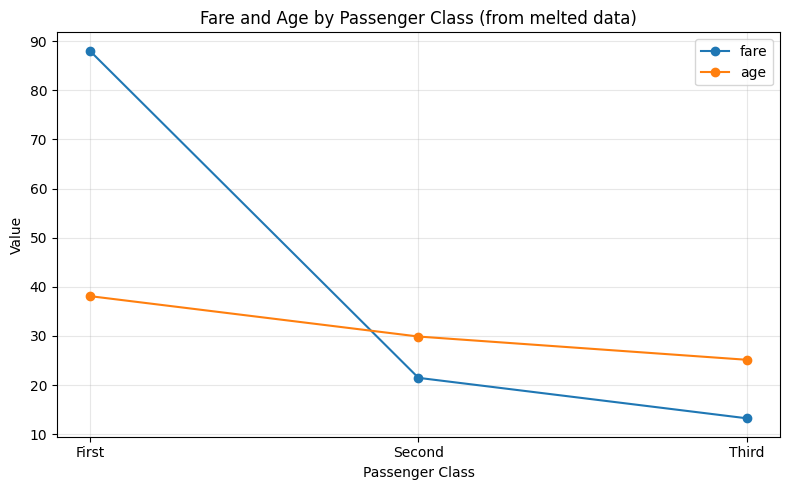

In [6]:
# Create a small wide-format summary table
# Mean fare and age by passenger class
class_summary_wide = df_clean.groupby('class')[['fare', 'age']].mean()
print("Wide format (one column per metric):")
print(class_summary_wide.round(2))
print()

# Melt it to long format
class_summary_long = class_summary_wide.reset_index().melt(
    id_vars='class',           # columns to keep as-is
    value_vars=['fare', 'age'], # columns to unpivot
    var_name='metric',          # new column for the variable names
    value_name='value'          # new column for the values
)

print("Long format (one row per class-metric combination):")
print(class_summary_long.round(2))
print()

# Why is long format useful? It's ideal for plotting!
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
# In long format, we can easily group and visualize by class
for metric in class_summary_long['metric'].unique():
    subset = class_summary_long[class_summary_long['metric'] == metric]
    plt.plot(subset['class'], subset['value'], marker='o', label=metric)
plt.xlabel('Passenger Class')
plt.ylabel('Value')
plt.title('Fare and Age by Passenger Class (from melted data)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. `stack()` / `unstack()`: MultiIndex Reshaping Round-Trip

**`stack()`** pivots a column index (*column names*) into a row index (creates a multi-level index)
**`unstack()`** does the reverse—pivots a row index level into columns

These are useful for rotating data structures while preserving multi-level indexes.

In [7]:
# Start with a multi-column pivot table
multi_col_table = df_clean.pivot_table(
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean'
)

print("Original pivot table (columns = class):")
print(multi_col_table.round(3))
print(f"Shape: {multi_col_table.shape}")
print()

# Stack: move column index into row index (wider → taller)
stacked = multi_col_table.stack()
print("After stack() — moved columns to index:")
print(stacked.round(3))
print(f"Shape: {stacked.shape}")
print(f"Index levels: {stacked.index.nlevels}")
print()

# Unstack: restore—move the second index level back to columns
unstacked = stacked.unstack()
print("After unstack() — restored original shape:")
print(unstacked.round(3))
print(f"Shape: {unstacked.shape}")
print()

# Confirm they're equivalent
print("Are original and unstacked equal?", multi_col_table.equals(unstacked))

Original pivot table (columns = class):
class   First  Second  Third
sex                         
female  0.964   0.919  0.461
male    0.396   0.152  0.150
Shape: (2, 3)

After stack() — moved columns to index:
sex     class 
female  First     0.964
        Second    0.919
        Third     0.461
male    First     0.396
        Second    0.152
        Third     0.150
dtype: float64
Shape: (6,)
Index levels: 2

After unstack() — restored original shape:
class   First  Second  Third
sex                         
female  0.964   0.919  0.461
male    0.396   0.152  0.150
Shape: (2, 3)

Are original and unstacked equal? True


---
## 7. `crosstab()`: Counts and Normalized Category Rates

**`crosstab()`** is a specialized function for building frequency tables between two categorical columns.
- **Default**: counts of each combination
- **`normalize='index'`**: row-wise proportions (what % within each row?)
- **`normalize='columns'`**: column-wise proportions

In [8]:
# Crosstab: count passengers by sex and class
cross_counts = pd.crosstab(df_clean['sex'], df_clean['class'])
print("Passenger counts by sex and class:")
print(cross_counts)
print()

# Add margins (row and column totals)
cross_counts_with_margins = pd.crosstab(
    df_clean['sex'], 
    df_clean['class'],
    margins=True
)
print("With margins:")
print(cross_counts_with_margins)
print()

# Normalize by row: what percentage of each sex is in each class?
cross_normalized_rows = pd.crosstab(
    df_clean['sex'], 
    df_clean['class'],
    normalize='index'
)
print("Row-wise proportions (what % of each sex is in each class?)")
print(cross_normalized_rows.round(3))
print()

# Normalize by column: what percentage of each class is male vs female?
cross_normalized_cols = pd.crosstab(
    df_clean['sex'], 
    df_clean['class'],
    normalize='columns'
)
print("Column-wise proportions (what % of each class is male vs female?)")
print(cross_normalized_cols.round(3))

Passenger counts by sex and class:
class   First  Second  Third
sex                         
female     83      74    102
male      101      99    253

With margins:
class   First  Second  Third  All
sex                              
female     83      74    102  259
male      101      99    253  453
All       184     173    355  712

Row-wise proportions (what % of each sex is in each class?)
class   First  Second  Third
sex                         
female  0.320   0.286  0.394
male    0.223   0.219  0.558

Column-wise proportions (what % of each class is male vs female?)
class   First  Second  Third
sex                         
female  0.451   0.428  0.287
male    0.549   0.572  0.713


---
## Exercise 1: Build and Validate Pivot Tables

**Task**: Create a pivot table to compute the survival **rate** (`mean` of survived) by `embark_town` and `class`.

Include:
1. The 2D pivot table with embark_town in row index and class in columns
2. Validation checks (hints below)

In [16]:
# Your code here: build a pivot table

survival_by_embark_class = df_clean.pivot_table(
    values='survived',
    index='embark_town',
    columns='class',
    aggfunc='mean'
)

print("Survival rate by embark town and class:")
print(survival_by_embark_class.round(3))
print()

Survival rate by embark town and class:
class        First  Second  Third
embark_town                      
Cherbourg    0.716   0.533  0.439
Queenstown   0.500   0.500  0.250
Southampton  0.611   0.474  0.210



In [10]:
# Validation: Check your work
print("EXERCISE 1 VALIDATION:")
print()

# Check 1: Result should be a DataFrame
assert isinstance(survival_by_embark_class, pd.DataFrame), "Result should be a DataFrame"
print("✓ Result is a DataFrame")

# Check 2: Index should contain embark towns
expected_towns = set(df_clean['embark_town'].unique())
actual_towns = set(survival_by_embark_class.index)
assert actual_towns == expected_towns, f"Index mismatch. Expected {expected_towns}, got {actual_towns}"
print(f"✓ Correct index (embark towns): {sorted(actual_towns)}")

# Check 3: Columns should contain classes
expected_classes = set(df_clean['class'].unique())
actual_classes = set(survival_by_embark_class.columns)
assert actual_classes == expected_classes, f"Column mismatch. Expected {expected_classes}, got {actual_classes}"
print(f"✓ Correct columns (classes): {sorted(actual_classes)}")

# Check 4: No empty values (NaN should represent missing data, not errors)
print(f"✓ Shape: {survival_by_embark_class.shape}")

# Check 5: All survival rates should be between 0 and 1
# Note: may have NaN values, which is ok
valid_values = survival_by_embark_class.values[~np.isnan(survival_by_embark_class.values)]
assert np.all((valid_values >= 0) & (valid_values <= 1)), "Survival rates must be between 0 and 1"
print(f"✓ All survival rates in valid range [0, 1]")

print("\n✓ Exercise 1 passed all validation checks!")

EXERCISE 1 VALIDATION:

✓ Result is a DataFrame
✓ Correct index (embark towns): ['Cherbourg', 'Queenstown', 'Southampton']
✓ Correct columns (classes): ['First', 'Second', 'Third']
✓ Shape: (3, 3)
✓ All survival rates in valid range [0, 1]

✓ Exercise 1 passed all validation checks!


---
## Exercise 2: Sales-Style Wide-to-Long Reshape with `melt()`

**Task**: Create a synthetic sales DataFrame with months as rows and product categories as columns, then melt it to long format.

Create this data:
```
        Electronics  Clothing  Grocery
Month
Jan             500       400      600
Feb             450       420      580
Mar             520       410      610
Apr             510       430      620
```

Then melt it so the result has columns: `Month`, `Category`, `Sales`.

In [11]:
# Create the sales data
sales_wide = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr'],
    'Electronics': [500, 450, 520, 510],
    'Clothing': [400, 420, 410, 430],
    'Grocery': [600, 580, 610, 620]
})

print("Wide format (original):")
print(sales_wide)
print()

# Melt it to long format
# Keep 'Month' as the identifier, melt the product categories
sales_long = sales_wide.melt(
    id_vars='Month',
    value_vars=['Electronics', 'Clothing', 'Grocery'],
    var_name='Category',
    value_name='Sales'
)

print("Long format (melted):")
print(sales_long)
print()

# Compute total sales by category
sales_by_category = sales_long.groupby('Category')['Sales'].sum()
print("Total sales by category (from melted data):")
print(sales_by_category)

Wide format (original):
  Month  Electronics  Clothing  Grocery
0   Jan          500       400      600
1   Feb          450       420      580
2   Mar          520       410      610
3   Apr          510       430      620

Long format (melted):
   Month     Category  Sales
0    Jan  Electronics    500
1    Feb  Electronics    450
2    Mar  Electronics    520
3    Apr  Electronics    510
4    Jan     Clothing    400
5    Feb     Clothing    420
6    Mar     Clothing    410
7    Apr     Clothing    430
8    Jan      Grocery    600
9    Feb      Grocery    580
10   Mar      Grocery    610
11   Apr      Grocery    620

Total sales by category (from melted data):
Category
Clothing       1660
Electronics    1980
Grocery        2410
Name: Sales, dtype: int64


In [12]:
# Validation: Check your work
print("EXERCISE 2 VALIDATION:")
print()

# Check 1: sales_long should have more rows than sales_wide
assert len(sales_long) > len(sales_wide), "Melted data should have more rows"
print(f"✓ Correct shape: {len(sales_wide)} rows → {len(sales_long)} rows")

# Check 2: Required columns should exist
required_cols = {'Month', 'Category', 'Sales'}
actual_cols = set(sales_long.columns)
assert required_cols == actual_cols, f"Expected columns {required_cols}, got {actual_cols}"
print(f"✓ Correct columns: {sorted(required_cols)}")

# Check 3: 12 rows total (4 months × 3 categories)
assert len(sales_long) == 12, f"Expected 12 rows (4 months × 3 categories), got {len(sales_long)}"
print("✓ Correct row count (12)")

# Check 4: Verify groupby-sum is correct (spot check)
expected_electronics_total = 500 + 450 + 520 + 510
actual_electronics_total = sales_long[sales_long['Category'] == 'Electronics']['Sales'].sum()
assert expected_electronics_total == actual_electronics_total, f"Electronics total mismatch"
print(f"✓ Aggregation correct (Electronics total: {actual_electronics_total})")

print("\n✓ Exercise 2 passed all validation checks!")

EXERCISE 2 VALIDATION:

✓ Correct shape: 4 rows → 12 rows
✓ Correct columns: ['Category', 'Month', 'Sales']
✓ Correct row count (12)
✓ Aggregation correct (Electronics total: 1980)

✓ Exercise 2 passed all validation checks!


---
## Exercise 3: `stack()` / `unstack()` Round-Trip Validation

**Task**: 
1. Build a 2D pivot table (survival rate by sex, columns = class) 
2. Apply `stack()` to move columns into the index
3. Apply `unstack()` to restore the original shape
4. Validate that the unstacked result matches the original

In [13]:
# Build the pivot table
pivot_original = df_clean.pivot_table(
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean'
)

print("Original pivot table:")
print(pivot_original.round(3))
print(f"Shape: {pivot_original.shape}")
print()

# Stack: move columns to row index
stacked_data = pivot_original.stack()
print("After stack():")
print(stacked_data.round(3))
print(f"Shape: {stacked_data.shape}")
print()

# Unstack: restore columns
unst_restored = stacked_data.unstack()
print("After unstack():")
print(unst_restored.round(3))
print(f"Shape: {unst_restored.shape}")
print()

Original pivot table:
class   First  Second  Third
sex                         
female  0.964   0.919  0.461
male    0.396   0.152  0.150
Shape: (2, 3)

After stack():
sex     class 
female  First     0.964
        Second    0.919
        Third     0.461
male    First     0.396
        Second    0.152
        Third     0.150
dtype: float64
Shape: (6,)

After unstack():
class   First  Second  Third
sex                         
female  0.964   0.919  0.461
male    0.396   0.152  0.150
Shape: (2, 3)



In [14]:
# Validation: Check your work
print("EXERCISE 3 VALIDATION:")
print()

# Check 1: Restored shape should match original
assert unst_restored.shape == pivot_original.shape, \
    f"Shape mismatch: {unst_restored.shape} != {pivot_original.shape}"
print(f"✓ Restored shape matches original: {unst_restored.shape}")

# Check 2: Restored data should equal original (allowing for NaN) 
# (Note: we use fillna comparison since == with NaN returns False)
original_filled = pivot_original.fillna(-999)
restored_filled = unst_restored.fillna(-999)
assert original_filled.equals(restored_filled), "Restored data does not match original"
print("✓ Restored data matches original")

# Check 3: Index should be identical
assert pivot_original.index.equals(unst_restored.index), "Index mismatch"
print(f"✓ Index matches: {list(pivot_original.index)}")

# Check 4: Columns should be identical
assert pivot_original.columns.equals(unst_restored.columns), "Columns mismatch"
print(f"✓ Columns match: {list(pivot_original.columns)}")

print("\n✓ Exercise 3 passed all validation checks!")

EXERCISE 3 VALIDATION:

✓ Restored shape matches original: (2, 3)
✓ Restored data matches original
✓ Index matches: ['female', 'male']
✓ Columns match: ['First', 'Second', 'Third']

✓ Exercise 3 passed all validation checks!


---
## Final Exercise: Titanic Wide-to-Long + Survival Rate by Sex and Class

**Task Flow**:
1. Create a temporary **wide** summary table with mean survival rate and passenger count for each (sex, class) combination
2. Use `melt()` to reshape it to long format
3. Then pivot back to compute the final **survival rate by sex and class** 
4. Validate the output

This demonstrates the full reshaping workflow!

In [21]:
# Step 1: Create a wide summary table with both metrics
wide_summary = df_clean.pivot_table(
    values=['survived', 'fare'],  # multiple metrics
    index='sex',
    columns='class',
    aggfunc='mean'
)

print("Step 1 - Wide summary table (multiple metrics):")
print(wide_summary.round(3))
print()

# Step 2: Flatten the multi-level columns and reset index for melting
wide_summary_flat = wide_summary.reset_index()
print("Step 2 - Flattened for melting:")
print(wide_summary_flat.round(3))
print(wide_summary_flat.columns)
print()

# Step 3: Melt to long format
# Ensure columns are truly flattened before melt (fixes KeyError on 'sex')
if isinstance(wide_summary_flat.columns, pd.MultiIndex):
    wide_summary_flat.columns = [
        'sex' if col[0] == 'sex' else f'{col[0]}_{col[1]}'
        for col in wide_summary_flat.columns
    ]

long_format = wide_summary_flat.melt(
    id_vars='sex',
    var_name='metric_class',
    value_name='value'
)
print("Step 3 - Melted to long format:")
print(long_format.head(10).round(3))
print()

# Step 4: Final pivot—survival rate by sex and class
final_pivot = df_clean.pivot_table(
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean'
)

print("Step 4 - Final result (survival rate by sex and class):")
print(final_pivot.round(3))

Step 1 - Wide summary table (multiple metrics):
           fare                 survived              
class     First  Second   Third    First Second  Third
sex                                                   
female  108.620  21.951  15.875    0.964  0.919  0.461
male     71.143  21.113  12.163    0.396  0.152  0.150

Step 2 - Flattened for melting:
          sex     fare                 survived              
class            First  Second   Third    First Second  Third
0      female  108.620  21.951  15.875    0.964  0.919  0.461
1        male   71.143  21.113  12.163    0.396  0.152  0.150
MultiIndex([(     'sex',       ''),
            (    'fare',  'First'),
            (    'fare', 'Second'),
            (    'fare',  'Third'),
            ('survived',  'First'),
            ('survived', 'Second'),
            ('survived',  'Third')],
           names=[None, 'class'])

Step 3 - Melted to long format:
      sex     metric_class    value
0  female       fare_First  108.620
1   

In [24]:
# Validation: Check your work
print("\nFINAL EXERCISE VALIDATION:")
print()

# Check 1: Result should be a 2D DataFrame
assert isinstance(final_pivot, pd.DataFrame), "Result should be a DataFrame"
assert final_pivot.ndim == 2, "Result should be 2D"
print("✓ Result is a 2D DataFrame")

# Check 2: Index should contain sex values
expected_sex = set(df_clean['sex'].unique())
actual_sex = set(final_pivot.index)
assert actual_sex == expected_sex, f"Index mismatch. Expected {expected_sex}, got {actual_sex}"
print(f"✓ Correct index (sex): {sorted(actual_sex)}")

# Check 3: Columns should contain class values
expected_class = set(df_clean['class'].unique())
actual_class = set(final_pivot.columns)
assert actual_class == expected_class, f"Column mismatch. Expected {expected_class}, got {actual_class}"
print(f"✓ Correct columns (class): {sorted(actual_class)}")

# Check 4: All survival rates should be between 0 and 1
flat_vals = final_pivot.values.flatten()
valid_vals = flat_vals[~np.isnan(flat_vals)]
assert np.all((valid_vals >= 0) & (valid_vals <= 1)), "Survival rates must be in [0, 1]"
print(f"✓ All survival rates in valid range [0, 1]")

# Check 5: Spot check—female first class had high survival rate
female_first_rate = final_pivot.loc['female', 'First']
assert female_first_rate > 0.9, f"Female 1st class survival rate should be high (>0.9), got {female_first_rate:.3f}"
print(f"✓ Known historical fact: Female 1st class had {female_first_rate:.1%} survival rate (historically accurate)")

print("\n✓ Final Exercise passed all validation checks!")


FINAL EXERCISE VALIDATION:

✓ Result is a 2D DataFrame
✓ Correct index (sex): ['female', 'male']
✓ Correct columns (class): ['First', 'Second', 'Third']
✓ All survival rates in valid range [0, 1]
✓ Known historical fact: Female 1st class had 96.4% survival rate (historically accurate)

✓ Final Exercise passed all validation checks!


---
## Key Takeaways

### Reshaping Pandas Cheat Sheet

| Task | Function | Example |
|---|---|---|
| **Pivot & Aggregate** | `df.pivot_table()` | `df.pivot_table(values='survived', index='sex', columns='class', aggfunc='mean')` |
| **Wide → Long** | `df.melt()` | `df.melt(id_vars='Month', var_name='metric', value_name='value')` |
| **Rotate columns to index** | `.stack()` | `df.stack()` → taller, narrower |
| **Rotate index to columns** | `.unstack()` | `df.unstack()` → shorter, wider |
| **Frequency table** | `pd.crosstab()` | `pd.crosstab(df['sex'], df['class'])` |

### When to Use Each Tool

- **`pivot_table()`**: Summarize & aggregate data into a 2D grid (like Excel pivot tables)
- **`melt()`**: Convert wide format to long format for plotting, modeling, or tidy analysis
- **`stack()` / `unstack()`**: Rotate multi-level indexes (advanced reshaping)
- **`crosstab()`**: Build frequency tables between categorical columns (fast frequency counts)

### Real-World Workflow

1. **Load raw data** (often wide format, like SQL joins)
2. **Clean & select columns** (remove noise, keep what matters)
3. **Reshape as needed**:
   - Use `pivot_table()` to summarize
   - Use `melt()` to prepare for plotting
   - Use `crosstab()` for categorical analysis
4. **Analyze** (visualize, model, report)

### Next Steps
- Practice melting real datasets and plotting them (long format is preferred for visualization)
- Combine `pivot_table()` with `margins=True` to compute grand totals
- Use `aggfunc=['mean', 'count', 'std']` to get multiple statistics at once

---
## Congratulations! 🎓

You've learned the core reshaping patterns used in nearly every data science project:
- ✓ Aggregating with **pivot tables**
- ✓ Converting between data formats with **melt**
- ✓ Rotating multi-level indexes with **stack/unstack**
- ✓ Building frequency tables with **crosstab**

These skills will make your data manipulation faster and your code cleaner. Practice applying them to real datasets!